In [1]:
!pip install pytrends

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pytrends.request import TrendReq

In [3]:
pytrends = TrendReq(hl='en-US', tz=360)

In [13]:
keywords = ["AI", "Robotics", "Data Science", "ChatGPT", "Online Learning"]

pytrends.build_payload(
    kw_list=keywords,
    timeframe='today 5-y',
    geo=''
)

data = pytrends.interest_over_time()
data = data.drop(columns=['isPartial'])
data.reset_index(inplace=True)

data.head()


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


,date,AI,Robotics,Data Science,ChatGPT,Online Learning
0,2020-12-13,4,0,0,0,0
1,2020-12-20,4,0,0,0,0
2,2020-12-27,4,0,0,0,0
3,2021-01-03,4,0,0,0,0
4,2021-01-10,4,0,0,0,0


In [6]:
data.isnull().sum()


,0
date,0
AI,0
Robotics,0
Data Science,0
ChatGPT,0
Online Learning,0


In [7]:
data[keywords] = data[keywords].astype(int)


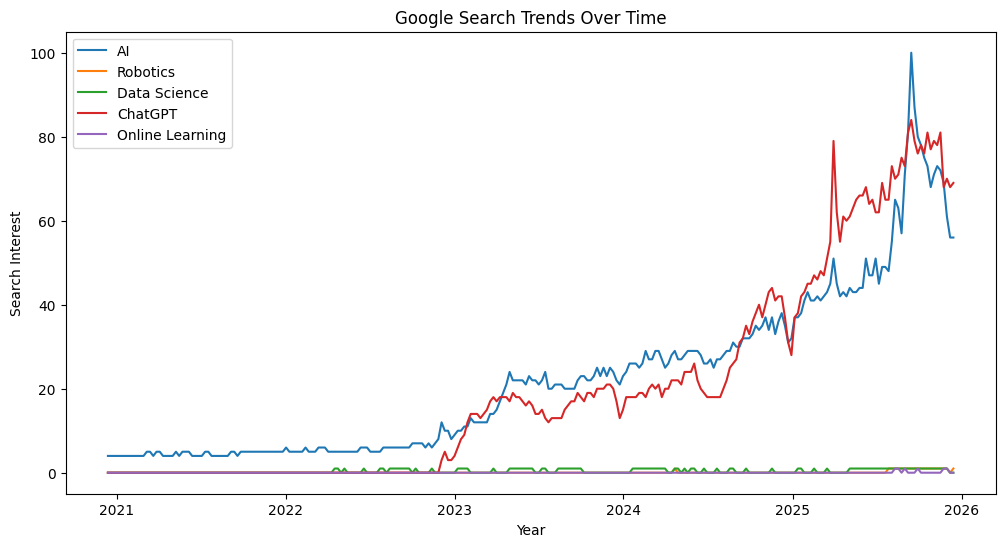

In [8]:
plt.figure(figsize=(12,6))
for kw in keywords:
    plt.plot(data['date'], data[kw], label=kw)

plt.title("Google Search Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Search Interest")
plt.legend()
plt.show()


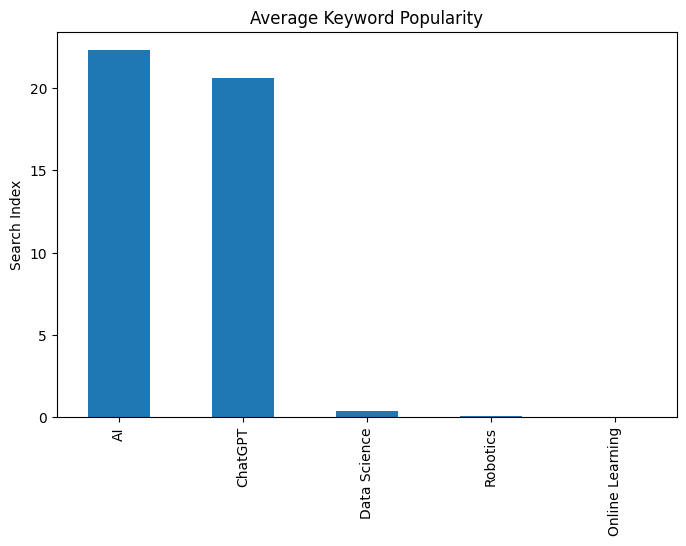

In [11]:
avg_popularity = data[keywords].mean().sort_values(ascending=False)
avg_popularity.plot(kind='bar', figsize=(8,5), title="Average Keyword Popularity")
plt.ylabel("Search Index")
plt.show()



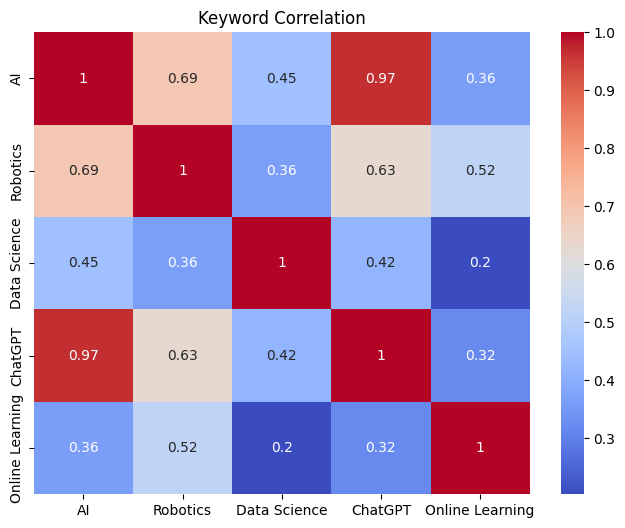

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(data[keywords].corr(), annot=True, cmap='coolwarm')
plt.title("Keyword Correlation")
plt.show()
